In [1]:
import numpy as np
import cv2
import joblib
from tensorflow.keras.models import load_model
import os
import random
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import plotly.io as pio
from plotly.offline import init_notebook_mode
import warnings

warnings.filterwarnings("ignore")
pio.renderers.default = "iframe"

2026-04-28 11:07:48.553574: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777374468.767771      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777374468.831547      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777374469.385675      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777374469.385706      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777374469.385709      16 computation_placer.cc:177] computation placer alr

# 1. Modelleri İçeri Aktarma

In [2]:
cnn_model = load_model('/kaggle/input/models/abdulkerimnee/cnn-emotion-model/keras/default/1/cnn_emotion_model.h5')
nlp_model = joblib.load('/kaggle/input/models/abdulkerimnee/nlp-model-v2/scikitlearn/default/1/nlp_model_v2.pkl')
tfidf_vectorizer = joblib.load('/kaggle/input/models/abdulkerimnee/tfidf-vectorizer-v2/scikitlearn/default/1/tfidf_vectorizer_v2.pkl')

2026-04-28 11:08:10.241792: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# 2. Fusion(Birleştirme) Fonksiyonu

In [3]:
# Sınıf İsimleri
cnn_classes = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

def multimodal_predict(text, image_path, text_weight=0.4, image_weight=0.6):
    """
    Hem metni hem fotoğrafı alıp ağırlıklı ortalama ile nihai duyguyu bulur.
    Görüntü (Mimikler) genelde daha güvenilir olduğu için ağırlığı (0.6) yüksek tutulmuştur.
    """
    
    # 1. NLP TAHMİNİ (Metin)
    text_vectorized = tfidf_vectorizer.transform([text])
    nlp_probs = nlp_model.predict_proba(text_vectorized)[0] 
    nlp_score_negative = nlp_probs[0]
    nlp_score_positive = nlp_probs[1]
    
    # 2. CNN TAHMİNİ (Görüntü)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return "HATA: Görsel okunamadı. Dosya yolunu kontrol edin."
    img_resized = cv2.resize(img, (48, 48))
    img_normalized = img_resized / 255.0
    img_reshaped = np.reshape(img_normalized, (1, 48, 48, 1))
    
    # CNN'in 7 sınıf için olasılıkları
    cnn_probs = cnn_model.predict(img_reshaped, verbose=0)[0]
    
    # 3. AĞIRLIKLI ORTALAMA (FUSION) İŞLEMİ
    final_probs = np.zeros(7)
    
    for i, emotion in enumerate(cnn_classes):
        if emotion in ['Happy', 'Surprise']:
            final_probs[i] = (cnn_probs[i] * image_weight) + (nlp_score_positive * text_weight)
        
        elif emotion in ['Angry', 'Disgust', 'Fear', 'Sad']:
            final_probs[i] = (cnn_probs[i] * image_weight) + (nlp_score_negative * text_weight)
            
        else:
            final_probs[i] = cnn_probs[i] 

    best_emotion_idx = np.argmax(final_probs)
    final_emotion = cnn_classes[best_emotion_idx]
    
    return final_emotion, final_probs

print("Fusion (Birleştirme) fonksiyonu hazır!")

Fusion (Birleştirme) fonksiyonu hazır!


# 3. Sonuçları Görselleştirme

In [4]:
init_notebook_mode(connected=True)
pio.renderers.default = 'kaggle' 

In [5]:
dataset_path = '/kaggle/input/datasets/msambare/fer2013'
test_dir = os.path.join(dataset_path, 'test')

In [6]:
emotions = [d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))]
random_emotion = random.choice(emotions)

emotion_folder_path = os.path.join(test_dir, random_emotion)
images_in_folder = os.listdir(emotion_folder_path)
random_image_file = random.choice(images_in_folder)

test_image_path = os.path.join(emotion_folder_path, random_image_file)

print(f"Başarıyla seçilen rastgele görselin yolu: {test_image_path}")
print(f"Bu görselin GERÇEK duygusu: {random_emotion.upper()}")

Başarıyla seçilen rastgele görselin yolu: /kaggle/input/datasets/msambare/fer2013/test/happy/PrivateTest_39819887.jpg
Bu görselin GERÇEK duygusu: HAPPY


In [7]:
# --- 1. METİN GİRDİSİ VE TAHMİN ---
test_text = "Bugün oldukça sıradan bir gün, pek bir şey hissetmiyorum."

# Fusion fonksiyonumuzu çağırıyoruz (Önceki hücrelerden geldiği varsayılır)
output = multimodal_predict(test_text, test_image_path)


1. AŞAMA: SİSTEME VERİLEN FOTOĞRAF


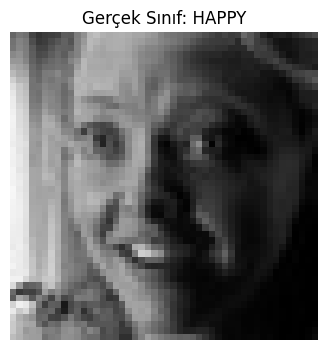


2. AŞAMA: MULTIMODAL YAPAY ZEKA KARARI


In [8]:
if isinstance(output, str):
    print("🚨 HATA:", output)
else:
    predicted_emotion, all_probabilities = output
    
   
    print("\n" + "="*50)
    print("1. AŞAMA: SİSTEME VERİLEN FOTOĞRAF")
    print("="*50)
    
    # Fotoğrafı OpenCV ile okuyup RGB'ye çevirme
    img_bgr = cv2.imread(test_image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f"Gerçek Sınıf: {random_emotion.upper()}")
    plt.axis('off')
    plt.show()

    
    print("\n" + "="*50)
    print("2. AŞAMA: MULTIMODAL YAPAY ZEKA KARARI")
    print("="*50)
    
    
    colors = ['#636EFA'] * 7 
    best_idx = cnn_classes.index(predicted_emotion)
    colors[best_idx] = '#EF553B' 
    
    fig = go.Figure(data=[go.Bar(
        x=cnn_classes, 
        y=all_probabilities, 
        marker_color=colors,
        text=np.round(all_probabilities, 3),
        textposition='auto'
    )])
    
    fig.update_layout(
        title_text=f"<b>NİHAİ TAHMİN: {predicted_emotion.upper()}</b><br><i>Kullanıcı Metni: '{test_text}'</i>",
        title_x=0.5,
        xaxis_title="Duygu Sınıfları",
        yaxis_title="Olasılık (0-1)",
        template="plotly_white",
        height=450
    )
    
    fig.show()

In [9]:
emotions = [d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))]
random_emotion = random.choice(emotions)

emotion_folder_path = os.path.join(test_dir, random_emotion)
images_in_folder = os.listdir(emotion_folder_path)
random_image_file = random.choice(images_in_folder)

test_image_path = os.path.join(emotion_folder_path, random_image_file)

print(f"Başarıyla seçilen rastgele görselin yolu: {test_image_path}")
print(f"Bu görselin GERÇEK duygusu: {random_emotion.upper()}")

test_text = "Hayatımda aldığım en güzel haber bu, inanamıyorum!"

output = multimodal_predict(test_text, test_image_path)

Başarıyla seçilen rastgele görselin yolu: /kaggle/input/datasets/msambare/fer2013/test/surprise/PrivateTest_94044652.jpg
Bu görselin GERÇEK duygusu: SURPRISE



1. AŞAMA: SİSTEME VERİLEN FOTOĞRAF


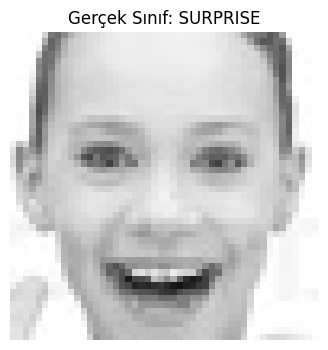


2. AŞAMA: MULTIMODAL YAPAY ZEKA KARARI


In [10]:
if isinstance(output, str):
    print("🚨 HATA:", output)
else:
    predicted_emotion, all_probabilities = output
    
    print("\n" + "="*50)
    print("1. AŞAMA: SİSTEME VERİLEN FOTOĞRAF")
    print("="*50)
    
    # Fotoğrafı OpenCV ile okuyup RGB'ye çevirme
    img_bgr = cv2.imread(test_image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f"Gerçek Sınıf: {random_emotion.upper()}")
    plt.axis('off')
    plt.show()

    
    print("\n" + "="*50)
    print("2. AŞAMA: MULTIMODAL YAPAY ZEKA KARARI")
    print("="*50)
    
    
    colors = ['#636EFA'] * 7 
    best_idx = cnn_classes.index(predicted_emotion)
    colors[best_idx] = '#EF553B' 
    
    fig = go.Figure(data=[go.Bar(
        x=cnn_classes, 
        y=all_probabilities, 
        marker_color=colors,
        text=np.round(all_probabilities, 3), 
        textposition='auto'
    )])
    
    fig.update_layout(
        title_text=f"<b>NİHAİ TAHMİN: {predicted_emotion.upper()}</b><br><i>Kullanıcı Metni: '{test_text}'</i>",
        title_x=0.5,
        xaxis_title="Duygu Sınıfları",
        yaxis_title="Olasılık (0-1)",
        template="plotly_white",
        height=450
    )
    
    fig.show()

In [11]:
emotions = [d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))]
random_emotion = random.choice(emotions)

emotion_folder_path = os.path.join(test_dir, random_emotion)
images_in_folder = os.listdir(emotion_folder_path)
random_image_file = random.choice(images_in_folder)

test_image_path = os.path.join(emotion_folder_path, random_image_file)

print(f"Başarıyla seçilen rastgele görselin yolu: {test_image_path}")
print(f"Bu görselin GERÇEK duygusu: {random_emotion.upper()}")

test_text = "Harika ya, tam da işe geç kalmışken üstüme kahve dökülmesi harika oldu!"

output = multimodal_predict(test_text, test_image_path)

Başarıyla seçilen rastgele görselin yolu: /kaggle/input/datasets/msambare/fer2013/test/happy/PrivateTest_31472026.jpg
Bu görselin GERÇEK duygusu: HAPPY



1. AŞAMA: SİSTEME VERİLEN FOTOĞRAF


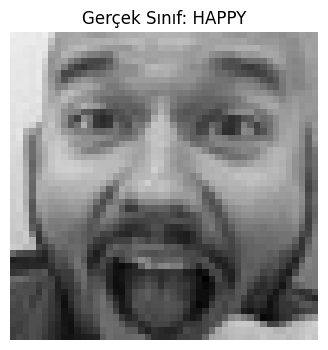


2. AŞAMA: MULTIMODAL YAPAY ZEKA KARARI


In [12]:
if isinstance(output, str):
    print("🚨 HATA:", output)
else:
    predicted_emotion, all_probabilities = output
    
    
    print("\n" + "="*50)
    print("1. AŞAMA: SİSTEME VERİLEN FOTOĞRAF")
    print("="*50)
    
    # Fotoğrafı OpenCV ile okuyup RGB'ye çevirme
    img_bgr = cv2.imread(test_image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f"Gerçek Sınıf: {random_emotion.upper()}")
    plt.axis('off')
    plt.show()

    
    print("\n" + "="*50)
    print("2. AŞAMA: MULTIMODAL YAPAY ZEKA KARARI")
    print("="*50)
    
    
    colors = ['#636EFA'] * 7 
    best_idx = cnn_classes.index(predicted_emotion)
    colors[best_idx] = '#EF553B'
    
    fig = go.Figure(data=[go.Bar(
        x=cnn_classes, 
        y=all_probabilities, 
        marker_color=colors,
        text=np.round(all_probabilities, 3), 
        textposition='auto'
    )])
    
    fig.update_layout(
        title_text=f"<b>NİHAİ TAHMİN: {predicted_emotion.upper()}</b><br><i>Kullanıcı Metni: '{test_text}'</i>",
        title_x=0.5,
        xaxis_title="Duygu Sınıfları",
        yaxis_title="Olasılık (0-1)",
        template="plotly_white",
        height=450
    )
    
    fig.show()